# Explore a GRS L2A image

This notebook walks through a single GRS **L2A** product (remote sensing reflectance, $R_{rs}$):

1. load the product into an `xarray` datacube with `grstbx.L2grs`;
2. inspect the pixel classification (`flags` bitmask);
3. display quick-looks (true colour, sunglint, aerosol, per-band maps);
4. mask non-water and too-bright pixels;
5. explore spectra interactively: draw points / polygons on a map and plot their $R_{rs}$ spectra and statistics;
6. derive simple water-quality parameters (Chl-a, CDOM, SPM) from empirical algorithms.

**Input:** a GRS L2A product, either a Zarr store (`*.zarr`, possibly a multiscale pyramid) or a
folder `<name>/` holding `<name>.nc` and `<name>_anc.nc`.

**Interactive cells:** sections 5 and 6 use `panel`/`holoviews` viewers. Draw on the map, then run the
following cells; when nothing is drawn they fall back to the whole image (or skip, for point spectra).

## 1. Libraries

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
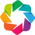

grs:    3.0.1dev
grstbx: 2.2.0


In [1]:
import os
import numpy as np
import xarray as xr
import rioxarray  # activate the .rio accessor
import matplotlib as mpl
import matplotlib.pyplot as plt
import panel as pn
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import grs
import grstbx
from grstbx import visual, utm_projection
from grstbx.masking import Masking
from grstbx.driver import zarr_levels

pn.extension()
opj = os.path.join

print(f'grs:    {grs.__version__}')
print(f'grstbx: {grstbx.__version__}')

Plotting settings shared by the cells below:

- `grstbx.utm_projection` returns the cartopy projection matching the image CRS (UTM for Sentinel-2 tiles);
- `CMAP_WQ` is the colormap used for $R_{rs}$ and water-quality maps.

In [2]:
CMAP_WQ = mpl.colors.LinearSegmentedColormap.from_list(
    'wq', ['navy', 'blue', 'lightskyblue', 'forestgreen', 'yellowgreen',
           'khaki', 'orangered', 'firebrick'])

## 2. Select and load the image

Browse to the product with the file selector below (select the `.zarr` store or the L2A folder),
or simply edit `DEFAULT_FILE`, which is used when nothing is selected.

In [3]:
workdir = '/data/satellite/Sentinel-2/test'
DEFAULT_FILE = opj(workdir,
                   'S2B_MSIL2AGRS_20200411T110619_N0500_R137_T30TWT_20230509T002033_V3.0.1dev',
                   'S2B_MSIL2AGRS_20200411T110619_N0500_R137_T30TWT_20230509T002033_V3.0.1dev.zarr')

selector = pn.widgets.FileSelector(workdir)
selector

FileSelector(directory='/data/satellite/Sentinel-..., root_directory='/data/satellite/Sentinel-...)

In [4]:
file = selector.value[0] if selector.value else DEFAULT_FILE
print(file)

/data/satellite/Sentinel-2/test/S2B_MSIL2AGRS_20200411T110619_N0500_R137_T30TWT_20230509T002033_V3.0.1dev/S2B_MSIL2AGRS_20200411T110619_N0500_R137_T30TWT_20230509T002033_V3.0.1dev.zarr


Zarr products may be stored as multiscale pyramids: group `'0'` is the full resolution (10, 20 or 60 m),
`'1'` is 2x coarser, etc. Opening a coarser `level` is much faster for a first look at a whole tile.

In [5]:
if file.rstrip('/').endswith('.zarr'):
    print('pyramid levels:', zarr_levels(file) or 'single resolution')

pyramid levels: ['0', '1', '2']


`L2grs.get_l2a_datacube` stacks the products along a `time` dimension and adds the proportion of pixels
raised for each flag (`flag_<name>` variables). Images with more than `nodata_thresh` nodata pixels are
discarded; `1.` keeps everything. The data stay lazy (dask) until they are plotted or computed.

In [6]:
level = 0  # pyramid level: 0 = full resolution, -1 = coarsest

dc = grstbx.L2grs([file], level=level)
dc.get_l2a_datacube(nodata_thresh=1.)

l2a_prod = dc.datacube.isel(time=0)
crs = l2a_prod.rio.crs
proj = utm_projection(crs)
l2a_prod

<xarray.Dataset> Size: 499MB
Dimensions:                          (y: 1830, x: 1830, wl: 11)
Coordinates:
    central_wavelength               (wl) float32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    spatial_ref                      int32 4B ...
    time                             datetime64[ns] 8B 2020-04-11T11:06:19
  * wl                               (wl) int64 88B 443 490 560 ... 1610 2190
  * x                                (x) float64 15kB 5e+05 ... 6.098e+05
  * y                                (y) float64 15kB 5.3e+06 ... 5.19e+06
Data variables: (12/27)
    BRDFg                            (y, x) float64 27MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    Rrs                              (wl, y, x) float64 295MB dask.array<chunksize=(11, 512, 512), meta=np.ndarray>
    aot550                           (y, x) float64 27MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    dem                              (y, x) float64 27MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    flags                            (y, x) uint32 13MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    mask                             (y, x) uint8 3MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    ...                               ...
    flag_surfwater_water             float64 8B 1.0
    flag_surfwater_cloud_and_shadow  float64 8B 0.0
    flag_OCM_Thick_Cloud             float64 8B 0.001599
    flag_OCM_Thin_Cloud              float64 8B 0.0
    flag_OCM_Cloud_Shadow            float64 8B 0.0002547
    flag_neg_rrs                     float64 8B 0.01831
Attributes: (12/81)
    CLOUD_COVERAGE_ASSESSMENT:           0.0133476663979217
    DATATAKE_1_DATATAKE_SENSING_START:   2020-04-11T11:06:19.024Z
    DATATAKE_1_DATATAKE_TYPE:            INS-NOBS
    DATATAKE_1_ID:                       GS2B_20200411T110619_016179_N05.00
    DATATAKE_1_SENSING_ORBIT_DIRECTION:  DESCENDING
    DATATAKE_1_SENSING_ORBIT_NUMBER:     137
    ...                                  ...
    vis_swir_index_threshold:            0.0
    water_vapor_transmittance_file:      /home/harmel/anaconda3/envs/py12/lib...
    wl_to_process:                       [443, 490, 560, 665, 705, 740, 783, ...
    pyramid_level:                       0
    start_date:                          2020-04-11T11:06:19.000000000
    stop_date:                           2020-04-11T11:06:19.000000000

Main variables of an L2A product:

| variable | description |
|---|---|
| `Rrs` | remote sensing reflectance (sr$^{-1}$), dims (`wl`, `y`, `x`) |
| `BRDFg` | sunglint reflectance estimated during the atmospheric correction |
| `aot550` | aerosol optical thickness at 550 nm |
| `sza`, `vza`, `raa` | solar zenith, viewing zenith and relative azimuth angles (deg) |
| `flags` | pixel classification bitmask (see next section) |
| `mask` | binary mask computed by GRS: 0 for valid water pixels |

## 3. Pixel classification (flags)

`flags` is an integer bitmask: bit *i* is raised when condition `flag_names[i]` holds. The names and
descriptions are stored in the attributes of the variable; `Masking` decodes them.

In [7]:
masking = Masking(l2a_prod)
masking.print_info().query("index != 'None'")

,description,bit,value
name,,,
nodata,nodata in input image,0,1
cloud_p06,low confidence cloud mask from s2cloudless wit...,1,2
cloud_p08,high confidence cloud mask from s2cloudless wi...,2,4
water_swir_visible_index,water mask from normalized index from swir and...,3,8
water_red_visible_index,water mask from normalized index from nir and ...,4,16
thin_cirrus,"thin cirrus mask from cirrus band, threshold 0...",5,32
opac_cirrus,"opac cirrus mask from cirrus band, threshold 0...",6,64
high_swir,"high swir (bright cloud, too bright reflection...",7,128
surfwater_land,land mask from surfwater input file,8,256


Map of every flag, with the proportion of pixels where it is raised:

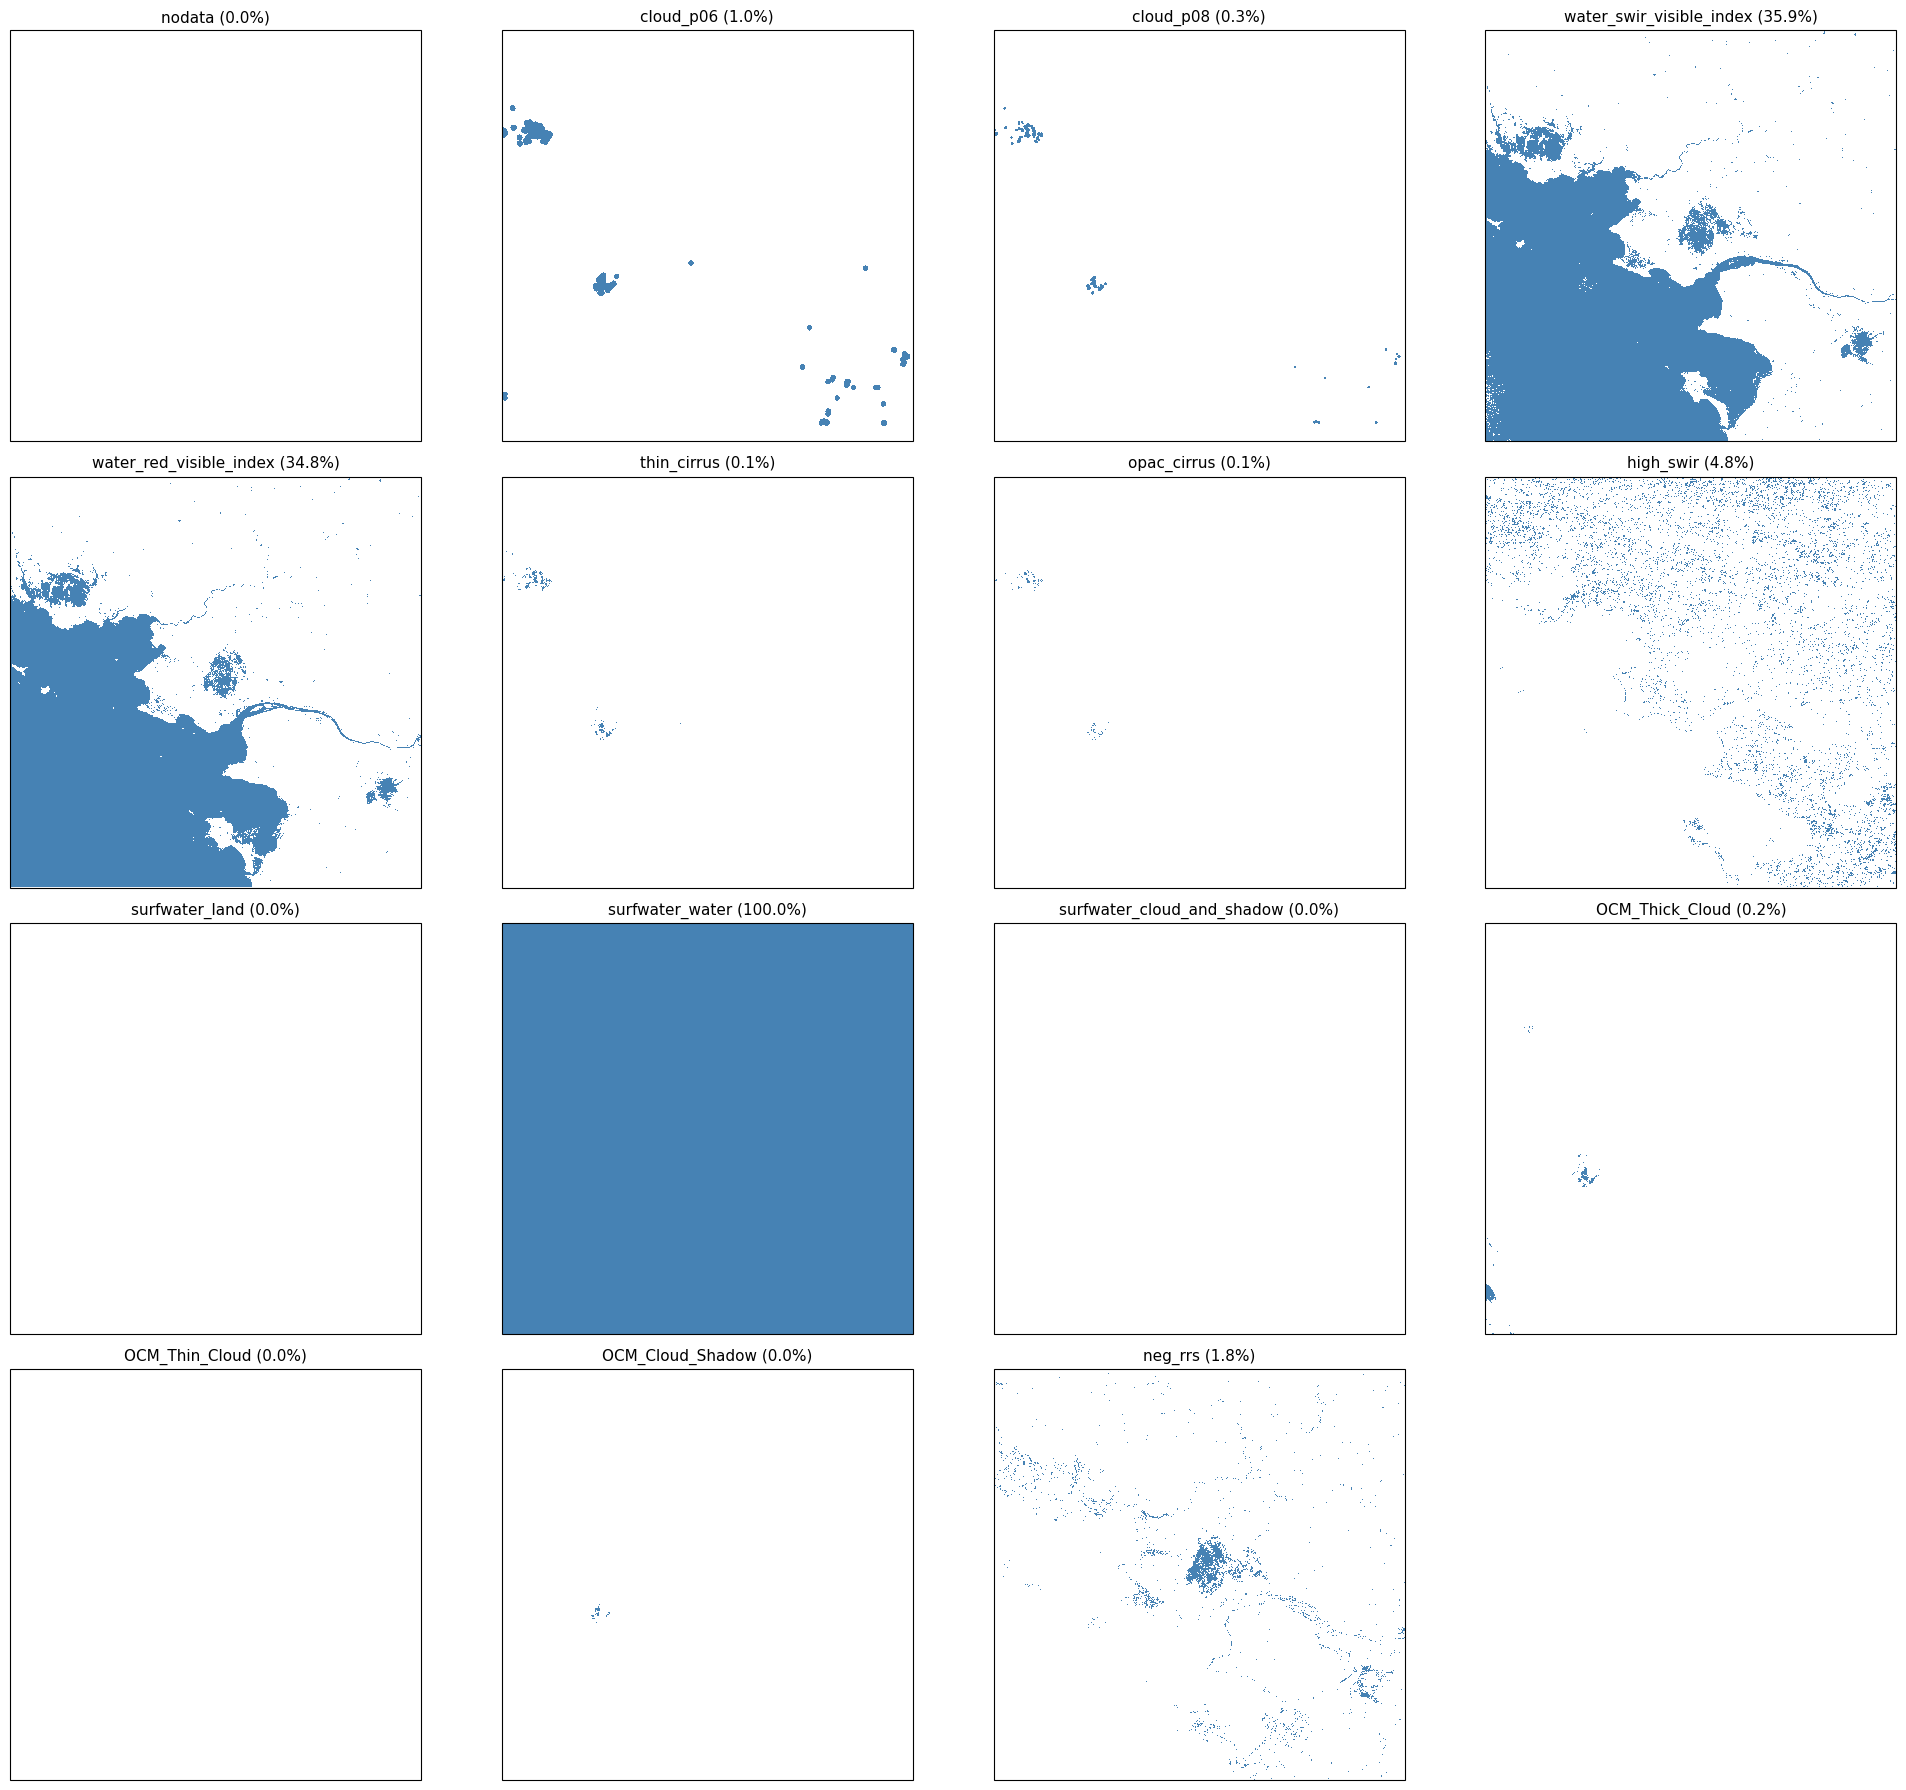

In [8]:
flags = l2a_prod.flags.astype(np.int64).compute()
flag_names = [name for name in flags.attrs['flag_names'] if name not in ('None', '')]
bcmap = mpl.colors.ListedColormap([(0, 0, 0, 0), 'steelblue'])

ncols = 4
nrows = int(np.ceil(len(flag_names) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                        subplot_kw={'projection': proj})
for ax, name in zip(axs.ravel(), flag_names):
    flag = Masking(xr.Dataset({'flags': flags})).get_mask(**{name: True})
    flag.plot.imshow(ax=ax, cmap=bcmap, vmin=0, vmax=1, add_colorbar=False)
    ax.set_title(f'{name} ({float(flag.mean()) * 100:.1f}%)', fontsize=11)
for ax in axs.ravel()[len(flag_names):]:
    ax.set_visible(False)
plt.tight_layout()

Selected flags overlaid on the true-colour image (edit `overlays` to change flags or colours):

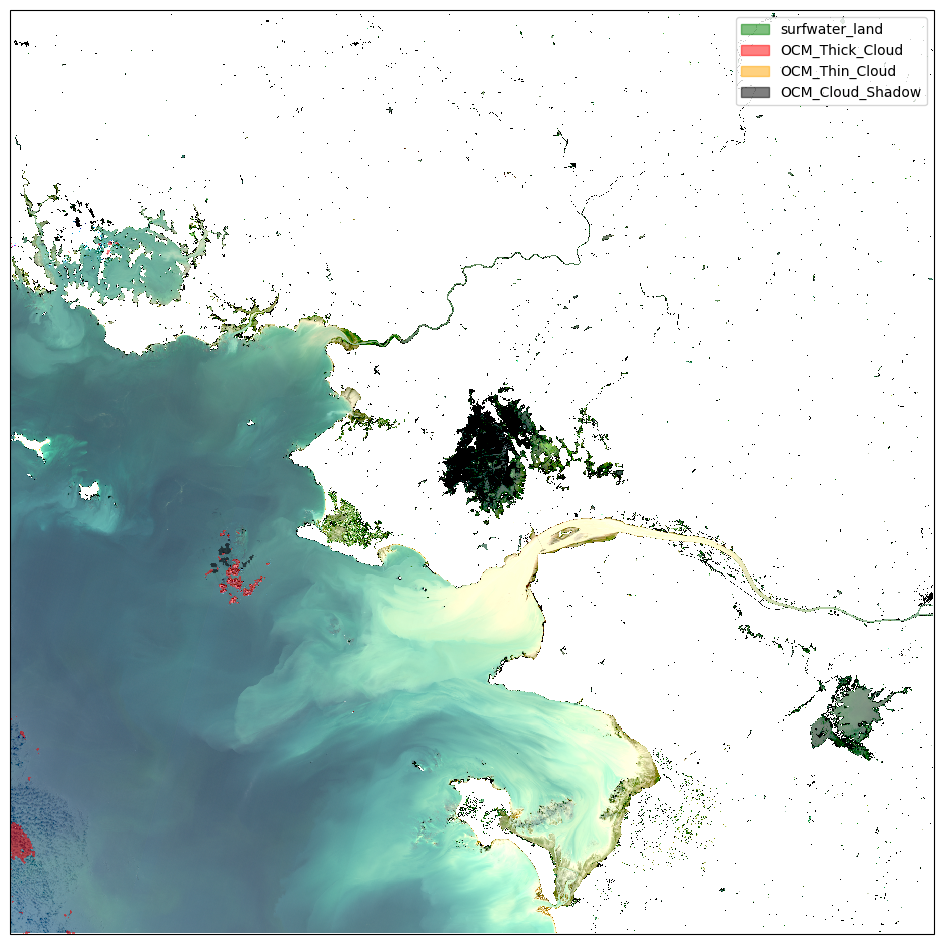

In [9]:
overlays = {'surfwater_land': 'green',
            'OCM_Thick_Cloud': 'red',
            'OCM_Thin_Cloud': 'orange',
            'OCM_Cloud_Shadow': 'black'}
alpha = 0.5

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': proj})
(l2a_prod.Rrs.sel(wl=[665, 560, 490], method='nearest').clip(min=0) ** 0.5).plot.imshow(rgb='wl', robust=True, ax=ax)
for name, color in overlays.items():
    if name not in flag_names:
        print(f'flag {name} not available in this product')
        continue
    flag = masking.get_mask(**{name: True})
    flag.plot.imshow(ax=ax, cmap=mpl.colors.ListedColormap([(0, 0, 0, 0), color]),
                     vmin=0, vmax=1, alpha=alpha, add_colorbar=False)
handles = [mpl.patches.Patch(color=c, alpha=alpha, label=n) for n, c in overlays.items() if n in flag_names]
ax.legend(handles=handles, loc='upper right')
ax.set_title('');

## 4. Quick-looks

True-colour composite (665, 560, 490 nm) and sunglint reflectance `BRDFg` over valid water pixels.

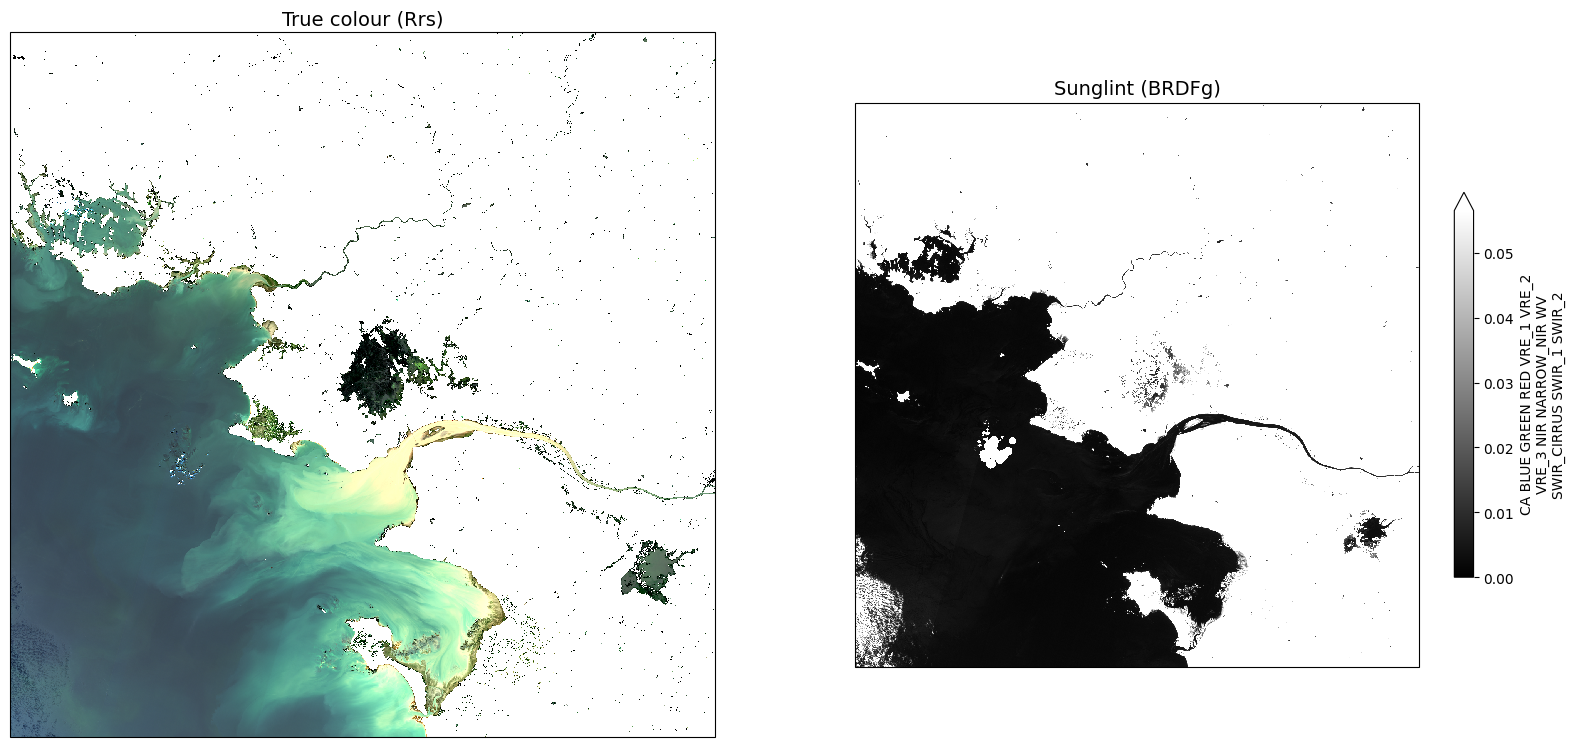

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10), subplot_kw={'projection': proj})
l2a_prod.Rrs.sel(wl=[665, 560, 490], method='nearest').plot.imshow(rgb='wl', robust=True, ax=axs[0])
axs[0].set_title('True colour (Rrs)', fontsize=14)
l2a_prod.BRDFg.where(l2a_prod.mask == 0).plot.imshow(
    cmap='gray', vmin=0, robust=True, ax=axs[1], cbar_kwargs={'shrink': 0.5})
axs[1].set_title('Sunglint (BRDFg)', fontsize=14);

Aerosol optical thickness at 550 nm and relative azimuth angle:

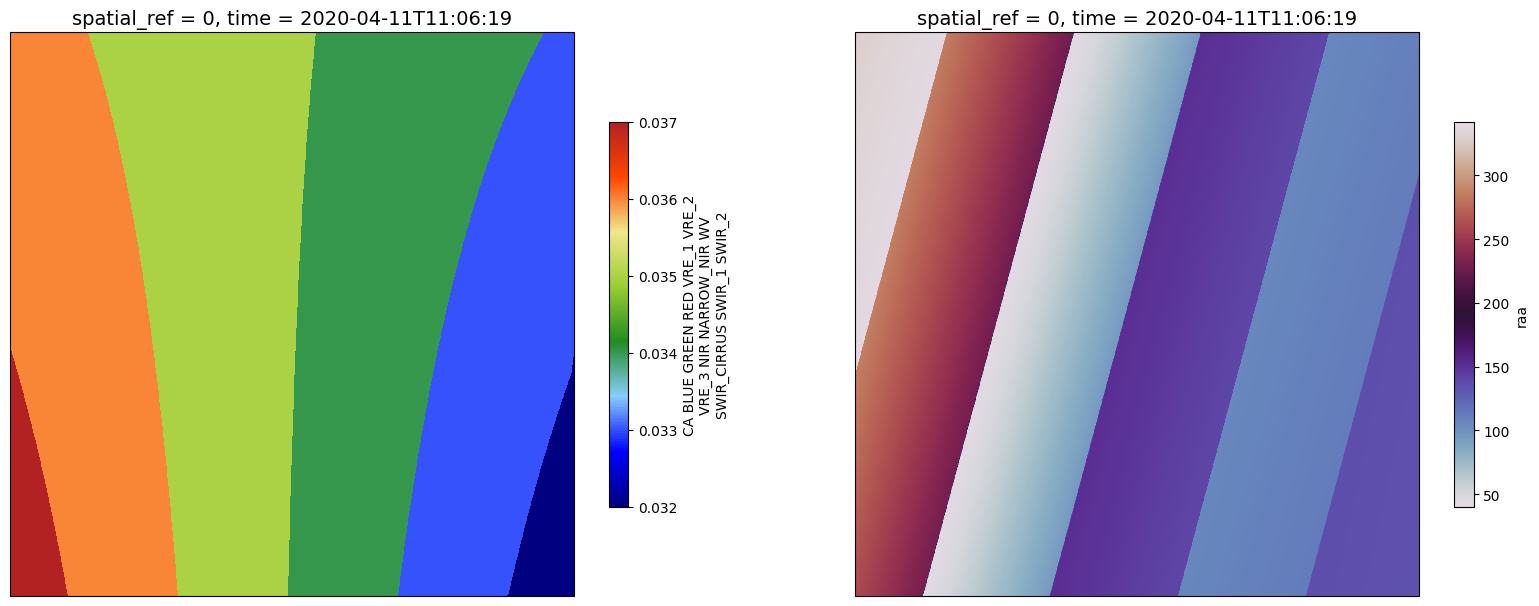

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10), subplot_kw={'projection': proj})
l2a_prod.aot550.plot.imshow(cmap=CMAP_WQ, robust=True, ax=axs[0], cbar_kwargs={'shrink': 0.5})
l2a_prod.raa.plot.imshow(cmap='twilight', ax=axs[1], cbar_kwargs={'shrink': 0.5})
for ax in axs:
    ax.set_title(ax.get_title(), fontsize=14)

## 5. Water pixels

Keep pixels flagged valid by GRS (`mask == 0`) and drop too-bright pixels (residual clouds, bright
bottom, ...) with a threshold on $R_{rs}(490)$. `l2a_prod` is left untouched; the masked reflectance is
stored in `Rrs_water`.

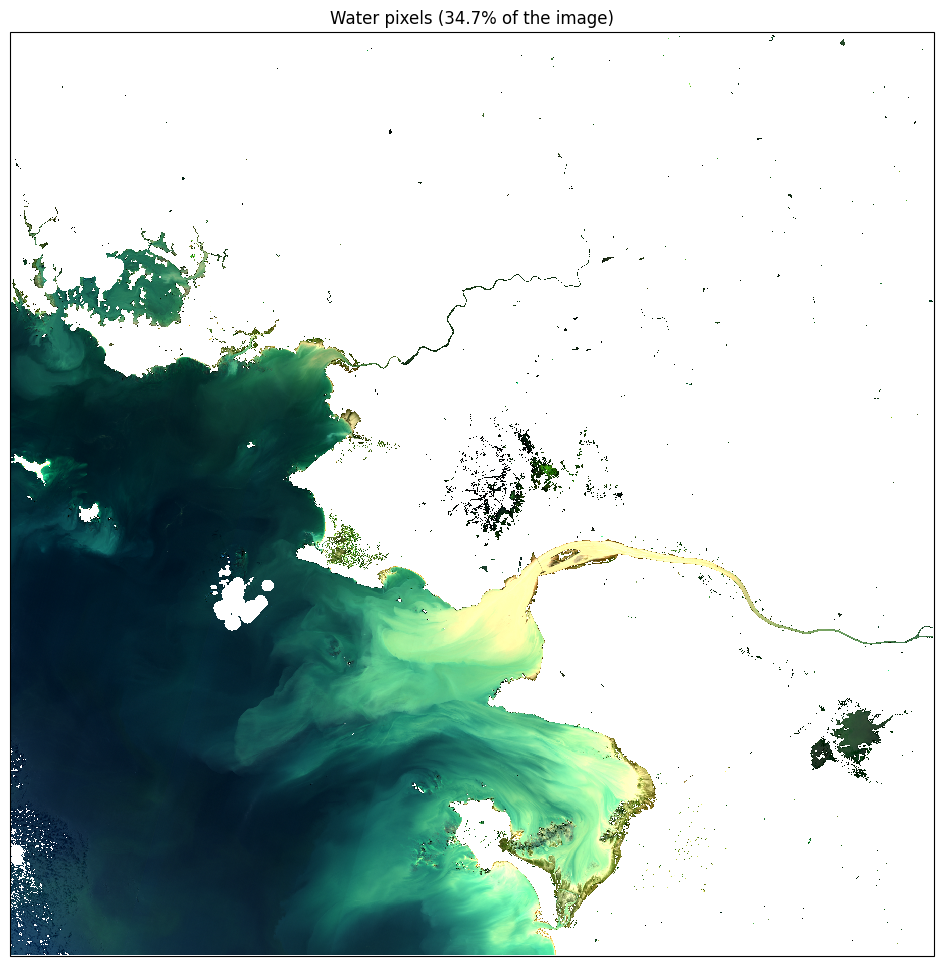

In [12]:
RRS490_MAX = 0.05  # sr-1, upper bound for Rrs(490) of water pixels

water = (l2a_prod.mask == 0) & (l2a_prod.Rrs.sel(wl=490, method='nearest') < RRS490_MAX)
Rrs_water = l2a_prod.Rrs.where(water)

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': proj})
Rrs_water.sel(wl=[665, 560, 490], method='nearest').plot.imshow(rgb='wl', robust=True, ax=ax)
ax.set_title(f'Water pixels ({float(water.mean()) * 100:.1f}% of the image)');

Map of each band in the visible / red-edge range over water:

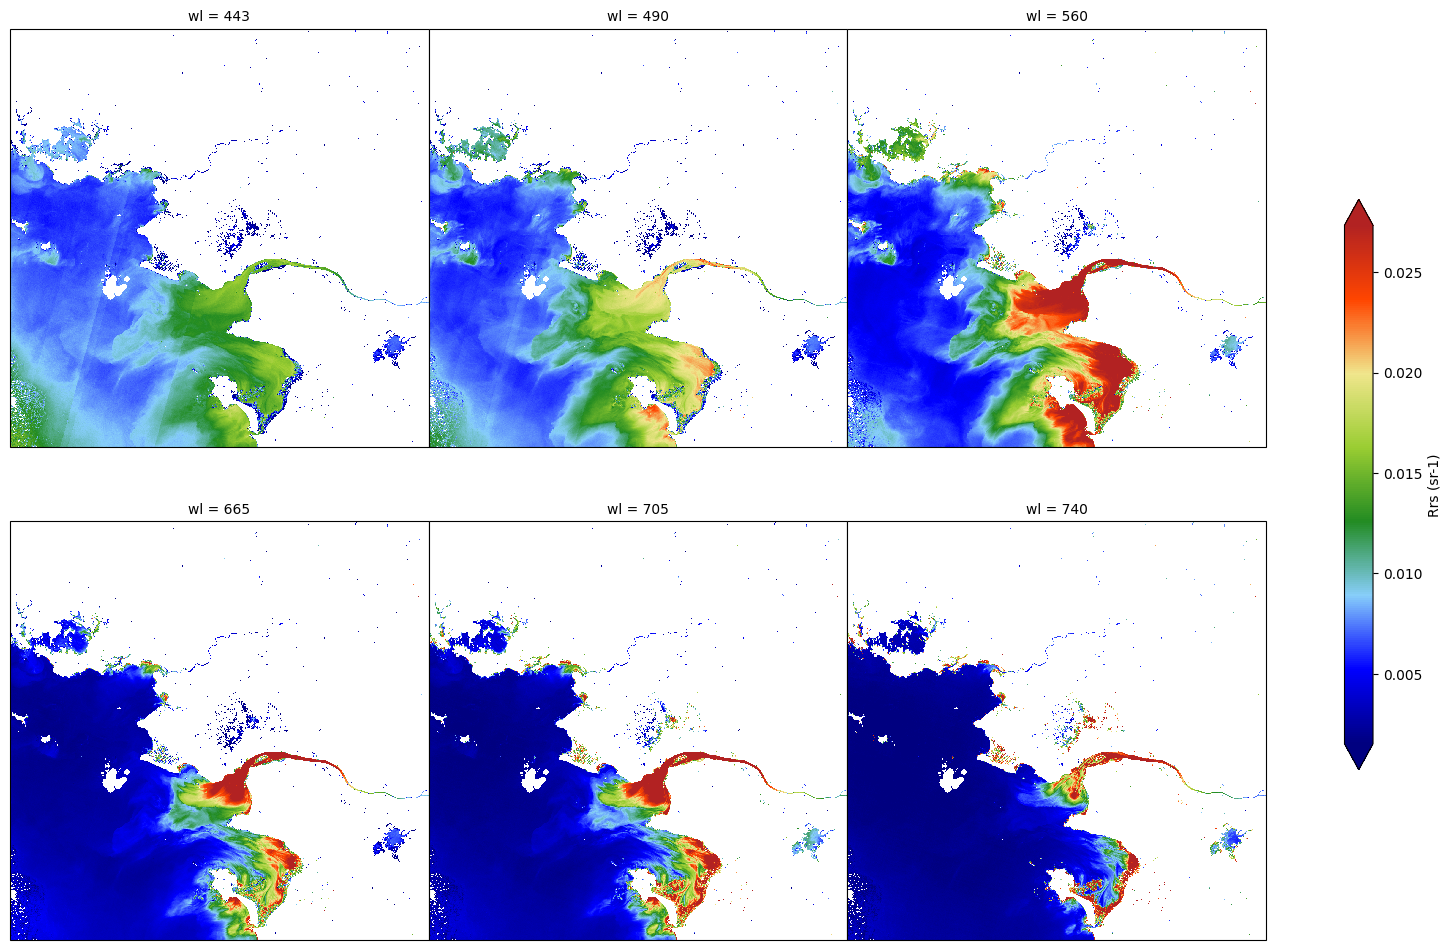

In [13]:
Rrs_water.sel(wl=slice(400, 750)).plot.imshow(
    col='wl', col_wrap=3, cmap=CMAP_WQ, robust=True, size=5,
    subplot_kws=dict(projection=proj), cbar_kwargs={'shrink': 0.6, 'label': 'Rrs (sr-1)'});

## 6. Interactive spectral exploration

`ViewSpectral` displays the image over a basemap (it is reprojected to EPSG:3857 for that).
Use the toolbar to:

- **Point Draw** tool: click to add points of interest (POI);
- **Polygon Draw** tool: double-click to start a polygon, click to add vertices, double-click to close it
  (areas of interest, AOI).

Then run the next cells: they read the drawn geometries from `viewer.poi_stream` and `viewer.aoi_stream`.

In [14]:
viewer = visual.ViewSpectral(Rrs_water, reproject=True, minmaxvalues=(0, 0.04), minmax=(0, 0.1))
viewer.visu()

Column
    [0] WidgetBox
        [0] Markdown(str)
        [1] Column
            [0] Row
                [0] Markdown(str)
                [1] RadioButtonGroup(options=[0, 1, 2, 3, 4, ...], value=2)
            [1] Row
                [0] Row
                    [0] Markdown(str)
                    [1] DatePicker(enabled_dates=[datetime.date(2020, ...], start=datetime.date(2020, ..., value=datetime.date(2020, ...)
                [1] Row
                    [0] Markdown(str)
                    [1] Select(options=['CartoDark', ...], value='CartoDark')
            [2] Row
                [0] Row
                    [0] Markdown(str)
                    [1] EditableRangeSlider(end=0.1, name='Range Slider', step=0.0001, value=(0, 0.04), width=300)
                [1] Row
                    [0] Markdown(str)
                    [1] FloatSlider(name='Opacity', step=0.05, value=0.95)
                [2] Row
                    [0] Markdown(str)
                    [1] Select(options=['CET_D13', 'bky', ...], value='CET_D13')
        [2] HoloViews(Layout)

### 6.1 Spectra of the drawn points

In [15]:
wl_zoom = slice(400, 900)

points = viewer.get_points(viewer.poi_stream, crs=crs)
if points.empty:
    print('No point drawn: add points with the Point Draw tool and rerun this cell.')
else:
    colors = plt.cm.turbo(np.linspace(0, 1, len(points)))
    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for ii, (pt, color) in enumerate(zip(points.geometry, colors)):
        spectrum = Rrs_water.sel(x=pt.x, y=pt.y, method='nearest')
        kw = dict(marker='o', ms=3.5, lw=1.5, c=color, alpha=0.7, label=f'pnt-{ii}')
        spectrum.plot(ax=axs[0], **kw)
        spectrum.sel(wl=wl_zoom).plot(ax=axs[1], **kw)
    for ax in axs:
        ax.set_xlabel('Wavelength (nm)')
        ax.set_ylabel('$R_{rs}$ (sr$^{-1}$)')
        ax.set_title('')
        ax.minorticks_on()
        ax.axhline(0, color='k', ls=':')
    axs[0].legend(fontsize=10)

No point drawn: add points with the Point Draw tool and rerun this cell.


### 6.2 Statistics over the drawn polygons

For each polygon: median (black), mean (red dashed) and 5–95 % percentile envelope of $R_{rs}$,
with a true-colour thumbnail of the clipped area.

In [16]:
def aoi_stats(da, dim='gridcell'):
    '''Per-wavelength statistics of the valid pixels of a (wl, y, x) DataArray.'''
    stacked = da.stack({dim: ['y', 'x']}).dropna(dim, how='all')
    return xr.Dataset({
        'median': stacked.median(dim),
        'mean': stacked.mean(dim),
        'std': stacked.std(dim),
        'q05': stacked.quantile(0.05, dim=dim).drop_vars('quantile'),
        'q95': stacked.quantile(0.95, dim=dim).drop_vars('quantile'),
        'pix_num': stacked.count(dim),
    }).compute()


def plot_aoi_stats(stats, clipped, title=''):
    fig, axs = plt.subplots(1, 2, figsize=(18, 6))
    axins = inset_axes(axs[0], width='45%', height='60%', loc=3,
                       bbox_to_anchor=(.55, .4, 0.9, 0.9), bbox_transform=axs[0].transAxes)
    clipped.sel(wl=[665, 560, 490], method='nearest').plot.imshow(rgb='wl', robust=True, ax=axins)
    axins.set_title('')
    axins.set_axis_off()
    for ax, stats_ in zip(axs, [stats, stats.sel(wl=wl_zoom)]):
        ax.minorticks_on()
        ax.axhline(0, color='k', lw=1)
        ax.plot(stats_.wl, stats_['median'], c='k', marker='o', ms=4, label='median')
        ax.plot(stats_.wl, stats_['mean'], c='red', ls='--', marker='o', ms=4, label='mean')
        ax.fill_between(stats_.wl, stats_['q05'], stats_['q95'], alpha=0.3, color='grey', label='5-95%')
        ax.set_xlabel('Wavelength (nm)')
        ax.set_ylabel('$R_{rs}$ (sr$^{-1}$)')
        ax.set_title(title)
    axs[1].legend()
    plt.show()


n_poly = len(viewer.aoi_stream.data.get('xs', []))
if n_poly == 0:
    print('No polygon drawn: draw polygons with the Polygon Draw tool and rerun this cell.')
date = str(l2a_prod.time.dt.date.values)
for index in range(n_poly):
    aoi = viewer.get_geom(viewer.aoi_stream, crs=crs, index=index)
    clipped = Rrs_water.rio.clip(aoi.geometry.values)
    stats = aoi_stats(clipped)
    plot_aoi_stats(stats, clipped,
                   title=f'{date}, polygon {index} ({int(stats.pix_num.max())} pixels)')

No polygon drawn: draw polygons with the Polygon Draw tool and rerun this cell.


### 6.3 Subset used for the water-quality products

The water-quality maps below are computed over the **last drawn polygon** when there is one,
otherwise over the whole image.

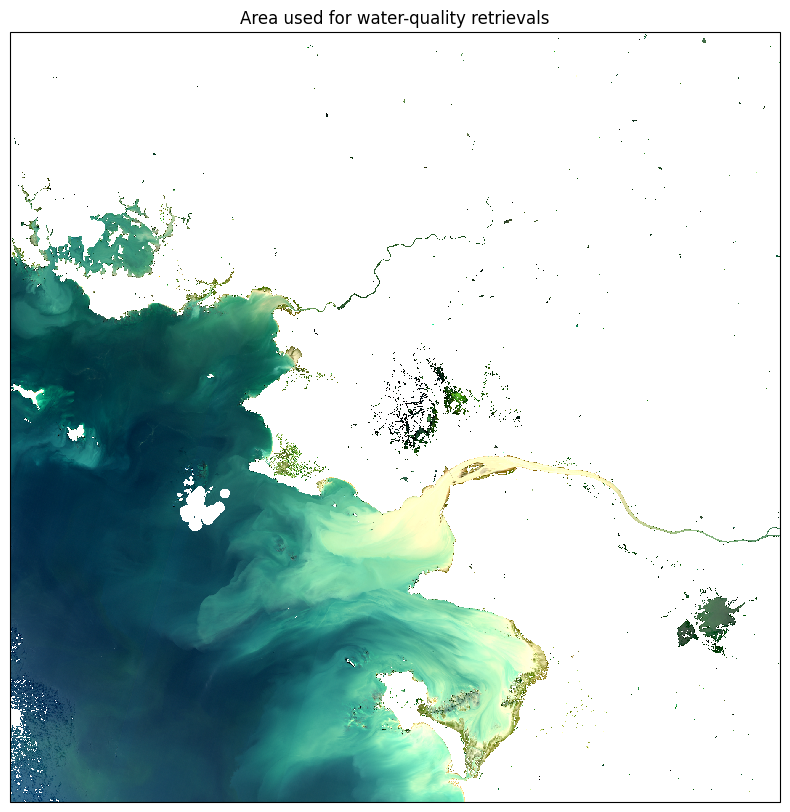

In [17]:
if n_poly > 0:
    aoi = viewer.get_geom(viewer.aoi_stream, crs=crs)
    Rrs_wq = Rrs_water.rio.clip(aoi.geometry.values)
else:
    Rrs_wq = Rrs_water
Rrs_wq = Rrs_wq.compute()

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})
(Rrs_wq.sel(wl=[665, 560, 490], method='nearest').clip(min=0) ** 0.5).plot.imshow(rgb='wl', robust=True, ax=ax)
ax.set_title('Area used for water-quality retrievals');

## 7. Water-quality parameters

Simple empirical algorithms, given for illustration: their coefficients were calibrated on specific
sensors / datasets and should be checked for your waters. Out-of-range values are discarded.

### 7.1 Chlorophyll-a: NASA OC2

$$\log_{10}(\mathrm{Chl}) = \sum_{i=0}^{4} a_i \left[\log_{10}\left(\frac{R_{rs}(\lambda_{blue})}{R_{rs}(\lambda_{green})}\right)\right]^i$$

Coefficients of the OCTS version (490 / 565 nm), applied to the Sentinel-2 bands 490 / 560 nm.
For the MODIS version (488 / 547 nm): `a = [0.2500, -2.4752, 1.4061, -2.8233, 0.5405]`.

/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


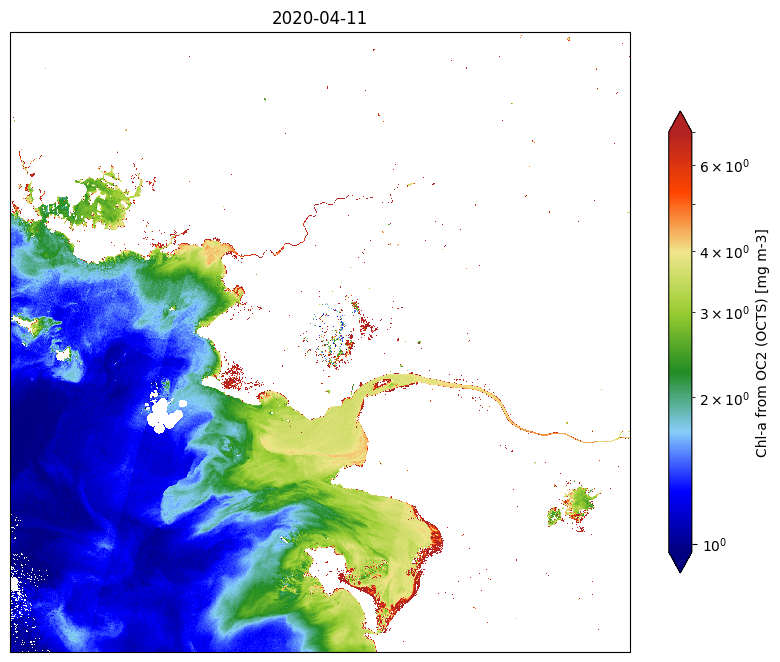

In [18]:
a = [0.2236, -1.8296, 1.9094, -2.9481, -0.1718]

ratio = np.log10(Rrs_wq.sel(wl=490, method='nearest') / Rrs_wq.sel(wl=560, method='nearest'))
chl = 10 ** sum(a_i * ratio ** i for i, a_i in enumerate(a))
chl = chl.where((chl >= 0) & (chl <= 280)).rename('chl_oc2')
chl.attrs = {'long_name': 'Chl-a from OC2 (OCTS)', 'units': 'mg m-3'}

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})
chl.plot.imshow(ax=ax, cmap=CMAP_WQ, norm=mpl.colors.LogNorm(*np.nanpercentile(chl, [2, 98])),
                cbar_kwargs={'shrink': 0.6})
ax.set_title(str(l2a_prod.time.dt.date.values));

### 7.2 CDOM absorption: Brezonik et al. (2015)

$$a_{CDOM}(440) = \exp\left(a_0 + a_1 \ln\frac{R_{rs}(490)}{R_{rs}(740)}\right)$$

/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)


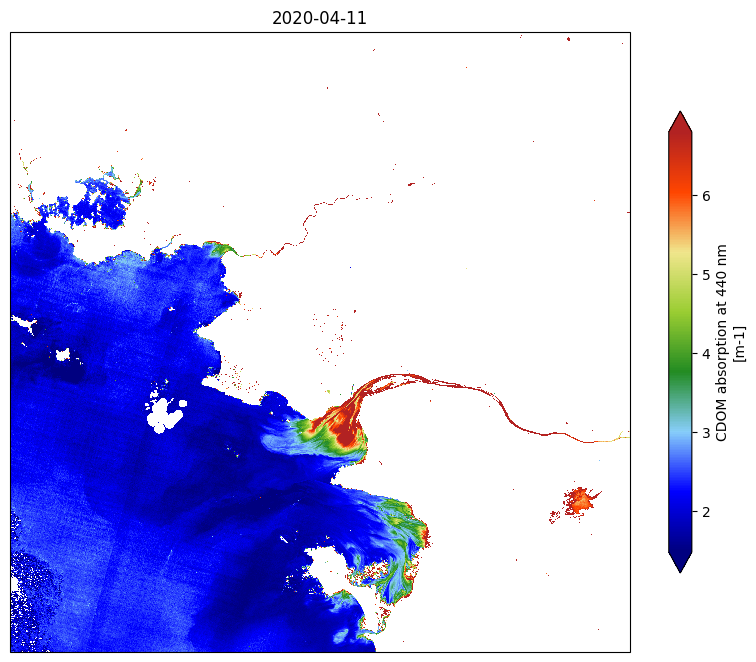

In [19]:
a = [1.872, -0.83]

acdom = np.exp(a[0] + a[1] * np.log(Rrs_wq.sel(wl=490, method='nearest') / Rrs_wq.sel(wl=740, method='nearest')))
acdom = acdom.where((acdom >= 0) & (acdom <= 10)).rename('acdom440')
acdom.attrs = {'long_name': 'CDOM absorption at 440 nm', 'units': 'm-1'}

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})
acdom.plot.imshow(ax=ax, cmap=CMAP_WQ, robust=True, cbar_kwargs={'shrink': 0.6})
ax.set_title(str(l2a_prod.time.dt.date.values));

### 7.3 Suspended particulate matter: Nechad et al. (2010, 2016)

$$\mathrm{SPM} = \frac{A\,\rho_w}{1 - \rho_w / C}, \qquad \rho_w = \pi R_{rs}$$

i.e. $\mathrm{SPM} = \dfrac{\pi A\,R_{rs}}{1 - R_{rs}/(C/\pi)}$, applied at 665 nm.

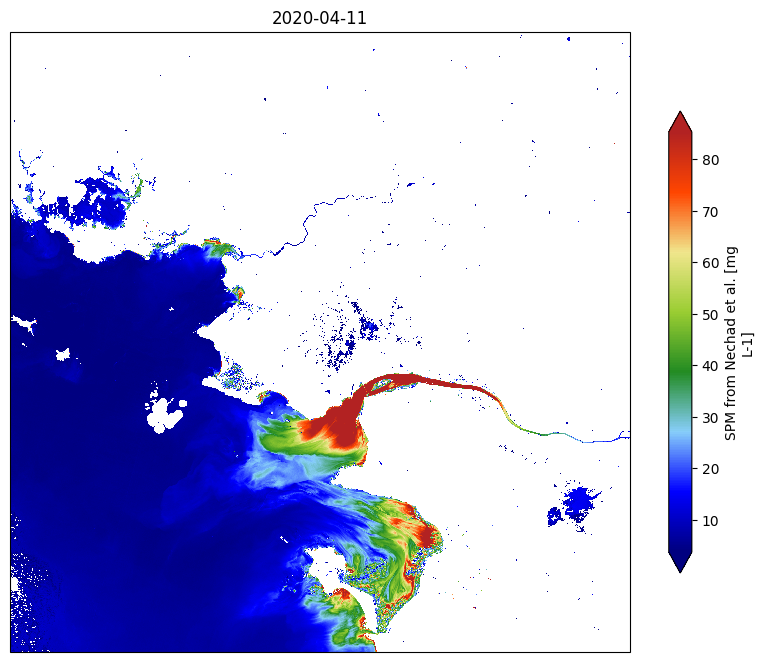

In [20]:
A, C = 610.94, 0.2324

Rrs_ = Rrs_wq.sel(wl=665, method='nearest')
spm = np.pi * A * Rrs_ / (1 - Rrs_ / (C / np.pi))
spm = spm.where((spm >= 0) & (spm <= 150)).rename('spm')
spm.attrs = {'long_name': 'SPM from Nechad et al.', 'units': 'mg L-1'}

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})
spm.plot.imshow(ax=ax, cmap=CMAP_WQ, robust=True, cbar_kwargs={'shrink': 0.6})
ax.set_title(str(l2a_prod.time.dt.date.values));

### 7.4 Interactive view of the water-quality maps

`ViewParam` displays each 2D variable of a Dataset over a basemap; pick the parameter, colormap and
colour range with the widgets.

In [21]:
wq = xr.Dataset({'chl_oc2': chl, 'acdom440': acdom, 'spm': spm})
wq_viewer = visual.ViewParam(wq, reproject=True, minmaxvalues=(0, 10), minmax=(0, 100))
wq_viewer.visu()

Column
    [0] WidgetBox
        [0] Markdown(str)
        [1] Column
            [0] Row
                [0] Row
                    [0] Markdown(str)
                    [1] Select(options=['chl_oc2', 'acdom440', ...], value='chl_oc2')
                [1] Row
                    [0] Markdown(str)
                    [1] DatePicker(enabled_dates=[datetime.date(2020, ...], start=datetime.date(2020, ..., value=datetime.date(2020, ...)
                [2] Row
                    [0] Markdown(str)
                    [1] Select(options=['CartoDark', ...], value='CartoDark')
            [1] Row
                [0] EditableRangeSlider(end=100, name='Range Slider', step=0.0001, value=(0, 10), width=300)
                [1] Row
                    [0] Markdown(str)
                    [1] FloatSlider(name='Opacity', step=0.05, value=0.95)
                [2] Row
                    [0] Markdown(str)
                    [1] Select(options=['CET_D13', 'bky', ...], value='CET_D13')
        [2] HoloViews(DynamicMap, height=800, sizing_mode='fixed', width=1200)